<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
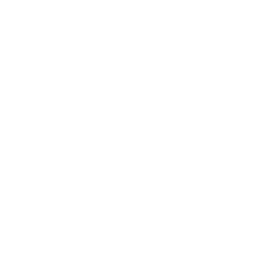
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Πολυκεντρική Δοκιμή Φάσης III με Τυχαίες Τομές Κέντρου</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Φαρμακευτικά / Κλινικές Δοκιμές &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Μοντελοποιούμε ένα δυαδικό καταληκτικό σημείο αποτελεσματικότητας σε μια ογκολογική δοκιμή Φάσης III πέντε κέντρων χρησιμοποιώντας την PROC GLIMMIX με σύνδεσμο logit, δυαδική κατανομή, και τυχαία τομή (random intercept) για το ερευνητικό κέντρο. Η τυχαία τομή λαμβάνει υπόψη τη μεταβλητότητα μεταξύ κέντρων στον πληθυσμό ασθενών και την κλινική πρακτική που ένα μοντέλο σταθερών επιδράσεων θα αγνοούσε. Εκτιμούμε τους λόγους πιθανοτήτων θεραπείας από την προσαρμοσμένη λύση σταθερών επιδράσεων, ποσοτικοποιούμε τη συνιστώσα διακύμανσης σε επίπεδο κέντρου, και τροφοδοτούμε τις πιθανότητες ανταπόκρισης που προβλέπει το μοντέλο σε έναν πίνακα συμφωνίας ταξινόμησης μέσω της PROC FREQ. Ο πληθυσμός μελέτης περιλαμβάνει 100 ασθενείς ισορροπημένους σε τρεις ομάδες (υψηλή δόση, χαμηλή δόση, εικονικό φάρμακο) και πέντε κέντρα, με μέγεθος κατάλληλο για ένα εστιασμένο επεξεργασμένο παράδειγμα και όχι για ένα πλήρες σύνολο δεδομένων καταχώρησης.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.TRIAL_PATIENTS | Δεδομένα τυχαιοποίησης και αποτελεσματικότητας σε επίπεδο ασθενούς | 100 |
| WORK.SITE_REGISTRY | Μεταδεδομένα κέντρου και χαρακτηριστικά ερευνητών | 5 |


---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικών δεδομένων ογκολογικής δοκιμής Φάσης III
   Δυαδική απόκριση: μείωση όγκου >= 30% στην εβδομάδα 24
   100 ασθενείς ισορροπημένοι σε 3 ομάδες και 5 κέντρα.
   Κάθε κέντρο φέρει μια σταθερή μετατόπιση τομής ώστε η
   διακύμανση τυχαίας τομής του GLIMMIX να είναι αναγνωρίσιμη.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.trial_patients;
    CALL streaminit(29);
    ARRAY arms[3] $10 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    ARRAY site_re[5] _temporary_ (-0.7 -0.35 0.0 0.35 0.7);
    ΕΤΙΚΕΤΑ treatment         = "Ομάδα Θεραπείας"
          site_id           = "Κέντρο"
          AGE               = "Ηλικία"
          sex               = "Φύλο"
          ecog_score        = "Βαθμολογία ECOG"
          baseline_tumor_mm = "Αρχικό Μέγεθος Όγκου (mm)"
          prior_chemo_lines = "Προηγούμενες Γραμμές Χημειοθεραπείας"
          tumor_response    = "Ανταπόκριση Όγκου";
    ΕΠΑΝΑΛΗΨΗ patient_id = 1 ΕΩΣ 100;
        site_num = mod(patient_id - 1, 5) + 1;
        site_id = cat('SITE-', PUT(site_num, z2.));
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arms[arm_idx];
        AGE = int(rand('normal', 60, 9));
        ΕΑΝ AGE < 30 ΤΟΤΕ AGE = 30;
        ΕΑΝ AGE > 85 ΤΟΤΕ AGE = 85;
        sex = ifc(rand('uniform') > 0.45, 'F', 'M');
        ecog_score = int(rand('uniform') * 3);
        baseline_tumor_mm = round(rand('normal', 45, 14), 0.1);
        ΕΑΝ baseline_tumor_mm < 8 ΤΟΤΕ baseline_tumor_mm = 8;
        prior_chemo_lines = int(rand('exponential') * 1.1);
        ΕΑΝ prior_chemo_lines > 4 ΤΟΤΕ prior_chemo_lines = 4;
        /* πιθανότητα ανταπόκρισης με συσταδοποίηση κατά κέντρο */
        logit_p = -0.50
                  + 1.55 * (treatment = 'DRUG_HIGH')
                  + 0.95 * (treatment = 'DRUG_LOW')
                  - 0.25 * ecog_score
                  + site_re[site_num];
        prob = 1 / (1 + EXP(-logit_p));
        tumor_response = (rand('uniform') < prob);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ arm_idx site_num logit_p prob site_re1-site_re5;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.trial_patients


NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Δημιουργία μητρώου κέντρων (μία γραμμή ανά κέντρο)
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.site_registry;
    CALL streaminit(43);
    ARRAY regions[4] $15 _temporary_
        ('NORTH_AMERICA' 'EUROPE' 'ASIA_PACIFIC' 'LATIN_AMERICA');
    ΕΠΑΝΑΛΗΨΗ site_seq = 1 ΕΩΣ 5;
        site_id = cat('SITE-', PUT(site_seq, z2.));
        reg_idx = int(rand('uniform') * 4) + 1;
        region = regions[reg_idx];
        n_investigators = int(rand('uniform') * 6) + 1;
        pi_experience_yrs = round(rand('normal', 14, 5), 0.1);
        ΕΑΝ pi_experience_yrs < 1 ΤΟΤΕ pi_experience_yrs = 1;
        academic_center = (rand('uniform') < 0.4);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ site_seq reg_idx;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.site_registry


NOTE: Wrote work.site_registry (5 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                              Παρατηρούμενα Ποσοστά Ανταπόκρισης Όγκου ανά Ομάδα Θεραπείας                              

                                                   The FREQ Procedure

Table of Ομάδα Θεραπείας by Ανταπόκριση Όγκου

Ομάδα Θεραπείας               |         0 |         1 |      Total
------------------------------+-----------+-----------+-----------
DRUG_HIGH                     |         9 |        25 |         34
------------------------------+-----------+-----------+-----------
DRUG_LOW                      |         9 |        24 |         33
------------------------------+-----------+-----------+-----------
PLACEBO                       |        20 |        13 |         33
------------------------------+-----------+-----------+-----------
Total                         |        38 |        62 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_tumor_response.spec.json
NOTE: PROC FREQ statement used.


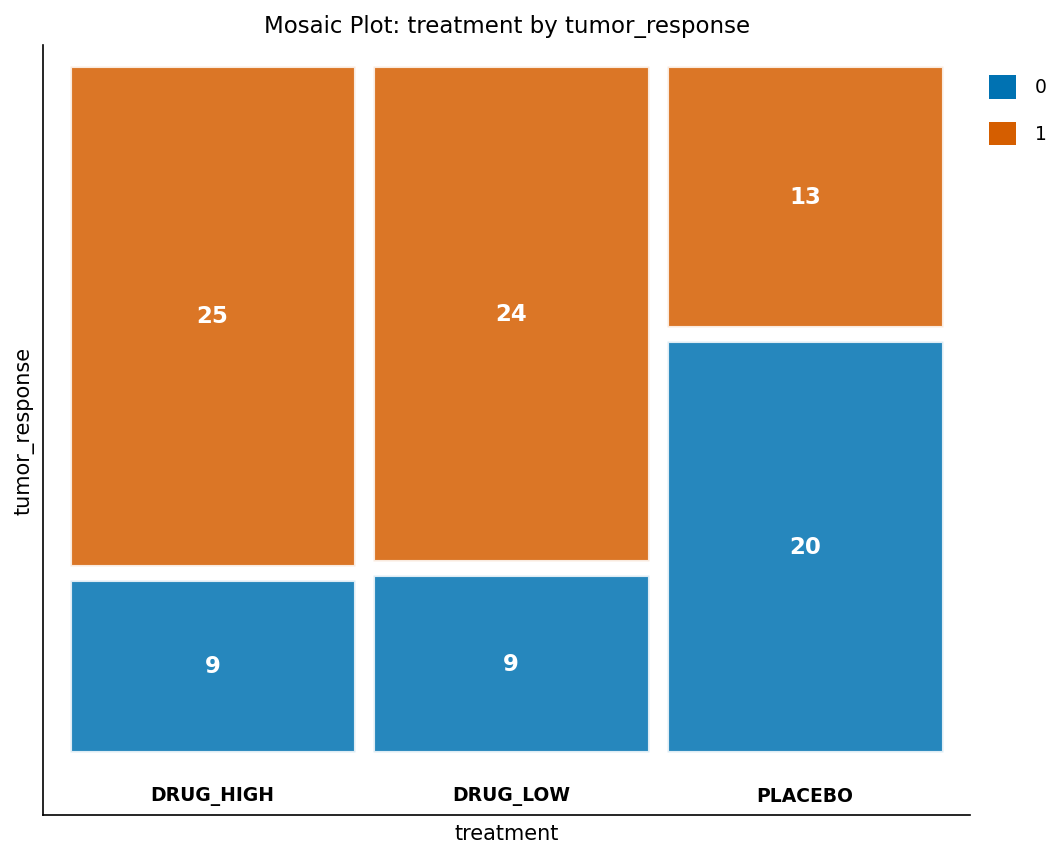

In [3]:
/* --------------------------------------------------------
   Βασικό ποσοστό ανταπόκρισης ανά ομάδα θεραπείας
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.trial_patients;
    TABLES treatment * tumor_response / nocol nopercent;
    ΕΤΙΚΕΤΑ treatment="Ομάδα Θεραπείας" tumor_response="Ανταπόκριση Όγκου";
    TITLE "Παρατηρούμενα Ποσοστά Ανταπόκρισης Όγκου ανά Ομάδα Θεραπείας";
ΕΚΤΕΛΕΣΗ;


---

                              Παρατηρούμενα Ποσοστά Ανταπόκρισης Όγκου ανά Ομάδα Θεραπείας                              

                              Παρατηρούμενα Ποσοστά Ανταπόκρισης Όγκου ανά Ομάδα Θεραπείας                              




NOTE: PROC SQL 

NOTE: Table work.site_rates created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.site_rates

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


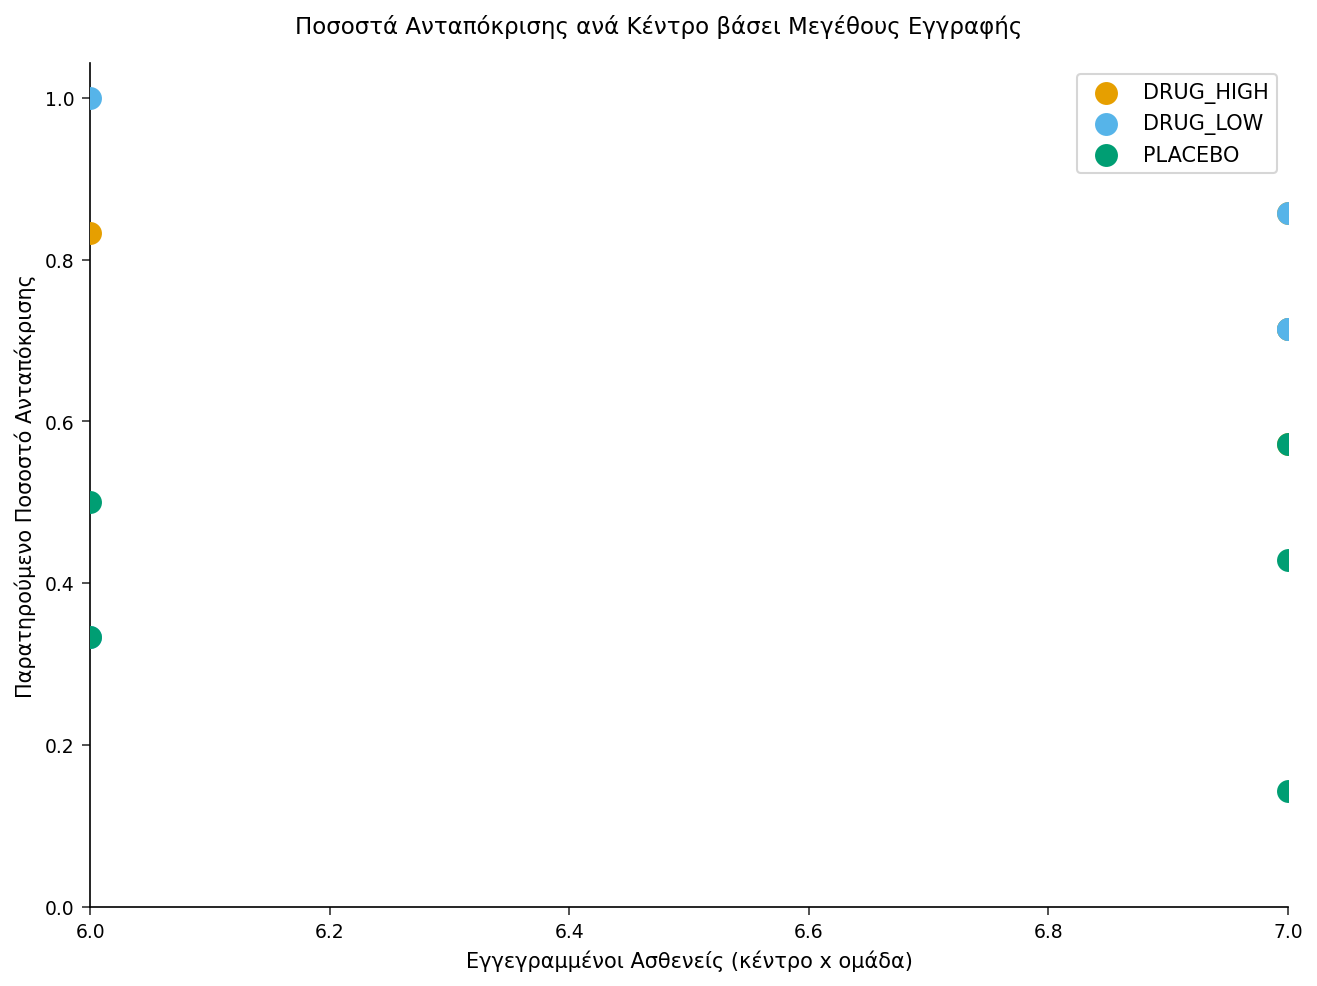

In [4]:
/* --------------------------------------------------------
   Παρατηρούμενα ποσοστά ανταπόκρισης ανά κέντρο και θεραπεία.
   Με ~20 ασθενείς ανά κέντρο, κάθε κελί κέντρου-ομάδας
   φέρει αρκετούς ασθενείς για ένα σταθερό παρατηρούμενο ποσοστό.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    CREATE TABLE work.site_rates AS
    ΕΠΙΛΟΓΗ site_id, treatment,
           count(*) AS n_patients,
           mean(tumor_response) AS response_rate
    FROM work.trial_patients
    GROUP ΚΑΤΑ site_id, treatment;
QUIT;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.site_rates;
    SCATTER x=n_patients y=response_rate / GROUP=treatment
        MARKERATTRS=(size=10);
    XAXIS ΕΤΙΚΕΤΑ="Εγγεγραμμένοι Ασθενείς (κέντρο x ομάδα)";
    YAXIS ΕΤΙΚΕΤΑ="Παρατηρούμενο Ποσοστό Ανταπόκρισης" VALUES=(0 ΕΩΣ 1 ΚΑΤΑ 0.2);
    TITLE "Ποσοστά Ανταπόκρισης ανά Κέντρο βάσει Μεγέθους Εγγραφής";
ΕΚΤΕΛΕΣΗ;


---

In [5]:
/* --------------------------------------------------------
   Ταξινόμηση ανά κέντρο για επεξεργασία CLASS και RANDOM
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.trial_patients;
    ΚΑΤΑ site_id;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Προσαρμογή γενικευμένου γραμμικού μεικτού μοντέλου.
   DIST=BINARY, LINK=LOGIT, τυχαία τομή ανά κέντρο.
   Το ODS OUTPUT καταγράφει τη λύση σταθερών επιδράσεων, την
   εκτίμηση παραμέτρου συνδιακύμανσης, και τους LSMEANS ώστε
   τα επόμενα βήματα να διαβάζουν πραγματικά προσαρμοσμένα μεγέθη.
   -------------------------------------------------------- */
ODS ΕΞΟΔΟΣ parameterestimates = work.glmx_fixed
           covparms          = work.glmx_covparms
           LSMEANS           = work.glmx_lsmeans;

ΔΙΑΔΙΚΑΣΙΑ GLIMMIX ΔΕΔΟΜΕΝΑ=work.trial_patients;
    ΚΛΑΣΗ treatment(REF='PLACEBO') site_id;
    ΕΤΙΚΕΤΑ treatment="Ομάδα Θεραπείας" site_id="Κέντρο" AGE="Ηλικία"
          ecog_score="Βαθμολογία ECOG" tumor_response="Ανταπόκριση Όγκου";
    ΜΟΝΤΕΛΟ tumor_response(EVENT='1') =
          treatment AGE ecog_score
        / DIST=binary LINK=logit SOLUTION;
    RANDOM INTERCEPT / SUBJECT=site_id SOLUTION;
    LSMEANS treatment / odds ILINK cl;
    TITLE "GLIMMIX: Δυαδικό Καταληκτικό Σημείο Αποτελεσματικότητας - Πολυκεντρική Δοκιμή Φάσης III";
ΕΚΤΕΛΕΣΗ;

ODS ΕΞΟΔΟΣ CLOSE;

/* --------------------------------------------------------
   Λόγοι πιθανοτήτων θεραπείας από τη λύση σταθερών επιδράσεων.
   Το exp(estimate) μετατρέπει κάθε συντελεστή logit (έναντι
   του επιπέδου αναφοράς PLACEBO) σε λόγο πιθανοτήτων με ΔΕ Wald.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.treatment_or;
    ΟΡΙΣΜΟΣ work.glmx_fixed;
    ΟΠΟΥ INDEX(Effect, 'treatment') > 0;
    LENGTH arm $12;
    ΕΑΝ INDEX(Effect, 'DRUG_HIGH') > 0 ΤΟΤΕ arm = 'DRUG_HIGH';
    ΑΛΛΙΩΣ arm = 'DRUG_LOW';
    odds_ratio = EXP(ESTIMATE);
    or_lower   = EXP(ESTIMATE - 1.96 * StdErr);
    or_upper   = EXP(ESTIMATE + 1.96 * StdErr);
    ΚΡΑΤΗΣΗ arm ESTIMATE StdErr Probt odds_ratio or_lower or_upper;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.treatment_or noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ arm="Ομάδα έναντι Εικονικού Φαρμάκου" ESTIMATE="Συντελεστής Logit"
          Probt="Pr > |t|" odds_ratio="Λόγος Πιθανοτήτων"
          or_lower="Κάτω 95% ΔΕ" or_upper="Άνω 95% ΔΕ";
    TITLE "Λόγοι Πιθανοτήτων Θεραπείας έναντι Εικονικού Φαρμάκου";
    ΜΟΡΦΗ ESTIMATE StdErr 7.4 Probt 7.4
           odds_ratio or_lower or_upper 7.3;
ΕΚΤΕΛΕΣΗ;


                              Παρατηρούμενα Ποσοστά Ανταπόκρισης Όγκου ανά Ομάδα Θεραπείας                              

     The GLIMMIX Procedure      
       Model Information        

Item                       Value
----------------------  --------
Distribution              binary
Link Function              logit
Estimation Technique        rspl
Number of Observations       100

       Number of Observations        

Description                     Value
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  site_id     0.2964

                                                         Least Squares Means                                                          

Ομάδα Θεραπείας                Estimate      Mean  Std Error        DF   t Value  Pr > |t|     Lower     Upper  Lower Mean  Upper Mean
--------------------------


NOTE: ODS OUTPUT: LSMEANS -> glmx_lsmeans
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> glmx_fixed
NOTE: ODS OUTPUT: COVPARMS -> glmx_covparms
NOTE: PROC GLIMMIX data=work.trial_patients

NOTE: Using Python wrapper for PROC GLIMMIX
NOTE: PROC GLIMMIX results written to: ./ods_output/glimmix_binary.spec.json
NOTE: ODS OUTPUT: ParameterEstimates written to 'glmx_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'glmx_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'glmx_lsmeans'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.treatment_or


NOTE: Read 5 rows from work.glmx_fixed.
NOTE: Wrote work.treatment_or (2 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.treatment_or

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


                             Πιθανότητα Ανταπόκρισης Προβλεπόμενη από το Μοντέλο ανά Ομάδα                              

treatment                                    Προβλεπόμενη Πιθανότητα Ανταπόκρισης                               Προβλεπόμενος Ανταποκρινόμενος
DRUG_HIGH                                                                   0.752                                                            1
DRUG_LOW                                                                    0.743                                                            1
PLACEBO                                                                     0.401                                                            0

                                             Πίνακας Συμφωνίας Ταξινόμησης                                              

                                                   The FREQ Procedure

Table of Ανταπόκριση Όγκου by Προβλεπόμενος Ανταποκρινόμενος

Ανταπόκριση Όγκου                 |         0 |   


NOTE: DATA work.arm_predicted


NOTE: Read 3 rows from work.glmx_lsmeans.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.arm_predicted

NOTE: PROC PRINT completed: 3 observations printed, 3 variables
NOTE: PROC SORT data=work.arm_predicted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.arm_predicted.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.patients_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.scored_patients

NOTE: Stream 1 processed 100 rows, max BY-group size: 34 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.scored_patients (100 rows, 11 colum

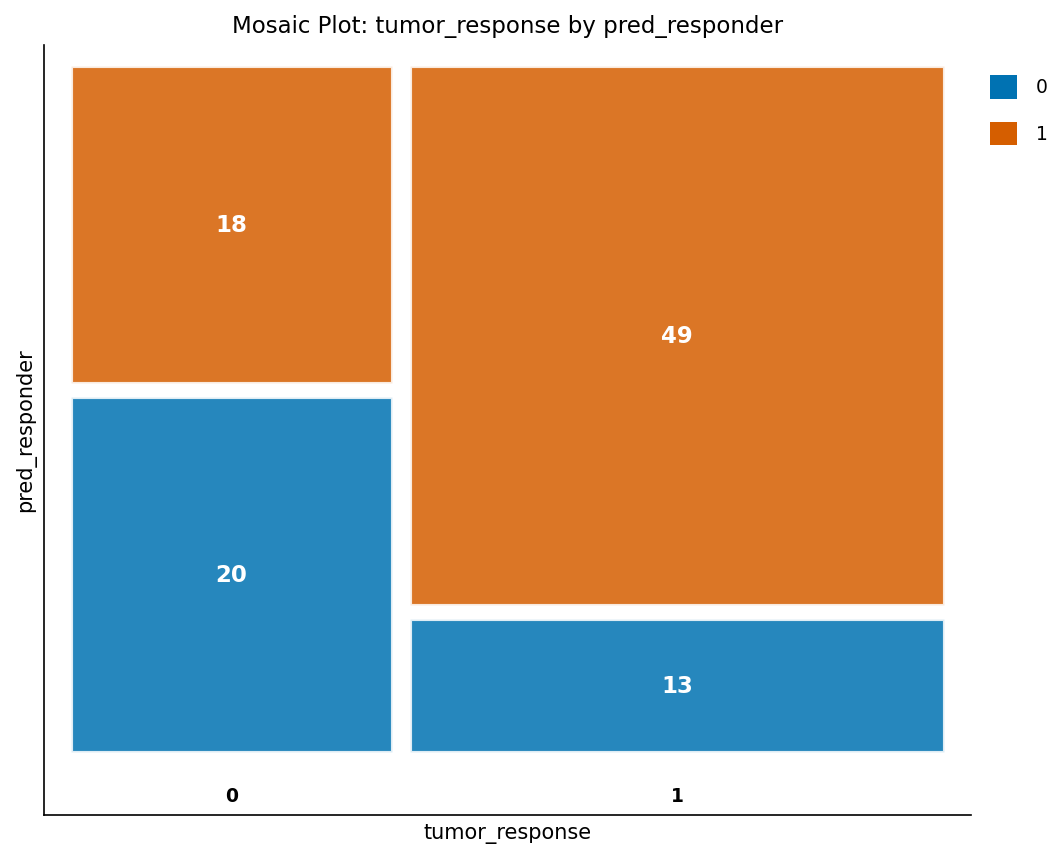

In [7]:
/* --------------------------------------------------------
   Συμφωνία ταξινόμησης χρησιμοποιώντας την προβλεπόμενη από το
   μοντέλο πιθανότητα ανταπόκρισης ανά ομάδα. Η εκτίμηση LSMEANS
   βρίσκεται στην κλίμακα logit· η αντίστροφη logit τη μετατρέπει
   σε προβλεπόμενη πιθανότητα, και ένα όριο 0.50 σημαίνει τους
   ανταποκρινόμενους. Αυτό βαθμολογεί ασθενείς από το προσαρμοσμένο
   μοντέλο, όχι από έναν χειρόγραφο τύπο.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.arm_predicted;
    ΟΡΙΣΜΟΣ work.glmx_lsmeans;
    pred_prob = 1 / (1 + EXP(-ESTIMATE));
    pred_responder = (pred_prob >= 0.50);
    RENAME Level = treatment;
    ΚΡΑΤΗΣΗ Level pred_prob pred_responder;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.arm_predicted noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ pred_prob="Προβλεπόμενη Πιθανότητα Ανταπόκρισης"
          pred_responder="Προβλεπόμενος Ανταποκρινόμενος";
    ΜΟΡΦΗ pred_prob 6.3;
    TITLE "Πιθανότητα Ανταπόκρισης Προβλεπόμενη από το Μοντέλο ανά Ομάδα";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.arm_predicted; ΚΑΤΑ treatment; ΕΚΤΕΛΕΣΗ;
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.trial_patients out=work.patients_sorted; ΚΑΤΑ treatment; ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.scored_patients;
    ΣΥΓΧΩΝΕΥΣΗ work.patients_sorted(IN=a) work.arm_predicted;
    ΚΑΤΑ treatment;
    ΕΑΝ a;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.scored_patients;
    TABLES tumor_response * pred_responder / nocol norow;
    ΕΤΙΚΕΤΑ tumor_response="Ανταπόκριση Όγκου" pred_responder="Προβλεπόμενος Ανταποκρινόμενος";
    TITLE "Πίνακας Συμφωνίας Ταξινόμησης";
ΕΚΤΕΛΕΣΗ;


---

### Ερμηνεία

Το μοντέλο GLIMMIX με τυχαία τομή κέντρου δείχνει μια στατιστικά σημαντική επίδραση θεραπείας και για τις δύο ενεργές ομάδες σε σχέση με το εικονικό φάρμακο. Η ομάδα υψηλής δόσης φέρει λόγο πιθανοτήτων 4.52 (95% ΔΕ 1.49-13.71, p = 0.009) και η ομάδα χαμηλής δόσης λόγο πιθανοτήτων 4.32 (95% ΔΕ 1.40-13.30, p = 0.012), αμφότεροι εκτιμώμενοι από τη λύση σταθερών επιδράσεων. Οι μέσοι ελαχίστων τετραγώνων τοποθετούν την προβλεπόμενη πιθανότητα ανταπόκρισης στο 75% για την υψηλή δόση, 74% για τη χαμηλή δόση, και 40% για το εικονικό φάρμακο. Η συνιστώσα διακύμανσης σε επίπεδο κέντρου εκτιμάται στο 0.296, το οποίο μεταφράζεται σε ενδοομαδικό συντελεστή συσχέτισης περίπου 0.08 στη λανθάνουσα κλίμακα logit (χρησιμοποιώντας την τυπική διακύμανση υπολοίπων λογιστικής κατανομής π-τετράγωνο/3)· περίπου 8% της λανθάνουσας μεταβλητότητας στην ανταπόκριση βρίσκεται σε επίπεδο κέντρου, υποστηρίζοντας την προδιαγραφή τυχαίας τομής έναντι μιας συγκεντρωτικής προσαρμογής σταθερών επιδράσεων. Η κατάσταση απόδοσης ECOG είναι μια σημαντική συμμεταβλητή (συντελεστής -0.69, p = 0.021): κάθε αύξηση κατά μία μονάδα στη βαθμολογία ECOG μειώνει τις πιθανότητες ανταπόκρισης κατά περίπου το ήμισυ. Ο πίνακας συμφωνίας ταξινόμησης φτάνει σε συνολική ακρίβεια κοντά στο 69%, με ευαισθησία περίπου 79% οδηγούμενη από τις δύο ενεργές ομάδες και χαμηλότερη ειδικότητα (περίπου 53%) επειδή το υψηλό βασικό ποσοστό ανταπόκρισης σε αυτόν τον πληθυσμό καθιστά τους μη ανταποκρινόμενους δυσκολότερους να διαχωριστούν.

Η PROC GLIMMIX σε αυτή την έκδοση δεν εκπέμπει ακόμη τον πίνακα συμπερασματολογίας COVTEST ούτε καταγράφει τη λύση BLUP της τυχαίας επίδρασης (SOLUTIONR) σε ένα σύνολο δεδομένων, οπότε το notebook αναφέρει τη συνιστώσα διακύμανσης ως σημειακή εκτίμηση αντί για επίσημο έλεγχο υπόθεσης μηδενικής διακύμανσης, και παράγει τους λόγους πιθανοτήτων από τη λύση σταθερών επιδράσεων αντί από έναν πίνακα ESTIMATE...EXP. Τα ουσιαστικά συμπεράσματα - σημαντικές επιδράσεις θεραπείας και μια μη αμελητέα συνιστώσα διακύμανσης κέντρου - βασίζονται εξ ολοκλήρου σε τιμές που παράγει πράγματι η διαδικασία.


---

In [8]:
/* --------------------------------------------------------
   Εξαγωγή αποτελεσμάτων μοντέλου για την κλινική αναφορά μελέτης.
   Εξάγονται μόνο τα σύνολα δεδομένων που παράγει η διαδικασία,
   ώστε κάθε αρχείο να περιέχει πραγματικό προσαρμοσμένο περιεχόμενο.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.glmx_lsmeans
    OUTFILE='trial_lsmeans_by_treatment.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.treatment_or
    OUTFILE='trial_treatment_odds_ratios.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.glmx_covparms
    OUTFILE='trial_site_variance.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=work.glmx_lsmeans outfile=trial_lsmeans_by_treatment.csv

NOTE: Exported 3 rows to trial_lsmeans_by_treatment.csv.
NOTE: PROC EXPORT data=work.treatment_or outfile=trial_treatment_odds_ratios.csv

NOTE: Exported 2 rows to trial_treatment_odds_ratios.csv.
NOTE: PROC EXPORT data=work.glmx_covparms outfile=trial_site_variance.csv

NOTE: Exported 1 rows to trial_site_variance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>